# **<font color="red">Logistic Regression - No Polynomial</font>**

Accuracy:  0.85
Confusion Matrix: 
 [[40  3]
 [12 45]]


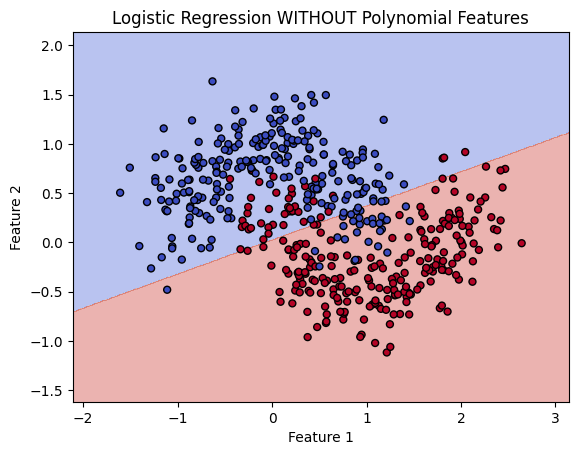

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Non-Linear Dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ####################### No Polynomial Features ########################
# Logistic Regression
lrc = LogisticRegression()
lrc.fit(X_train, y_train)
y_pred = lrc.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Accuracy: ", score)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))


# Plot Graph
def model_plot(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='coolwarm', edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

model_plot(lrc, X, y, "Logistic Regression WITHOUT Polynomial Features")



# **<font color="red">Logistic Regression - Polynomial</font>**

## **<font color="blue">Degree 3 </font>**

Accuracy:  0.93
Confusion Matrix:
 [[43  0]
 [ 7 50]]


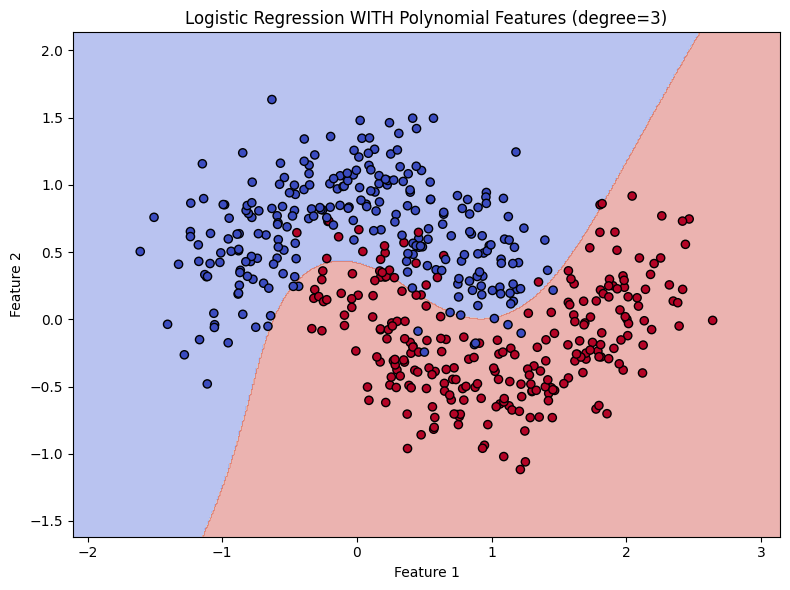

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Non-Linear Dataset
# -----------------------------
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Pipeline: PolynomialFeatures -> LogisticRegression
# -----------------------------
plrc = Pipeline([
    ("polynomial", PolynomialFeatures(degree=3)),  # By default degree = 2
    ("lrc", LogisticRegression(max_iter=5000))
])

# Fit and evaluate
plrc.fit(X_train, y_train)
y_pred = plrc.predict(X_test)

score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy: ", score)
print("Confusion Matrix:\n", cm)

# -----------------------------
# Decision boundary plotting
# -----------------------------
def model_plot(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # classifier can be a Pipeline; it will transform then predict
    Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, cmap='coolwarm', edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# Plot the pipeline's decision boundary over the original data
model_plot(plrc, X, y, "Logistic Regression WITH Polynomial Features (degree=3)")


## **<font color="blue">Degree 4 </font>**

Accuracy:  0.95
Confusion Matrix:
 [[43  0]
 [ 5 52]]


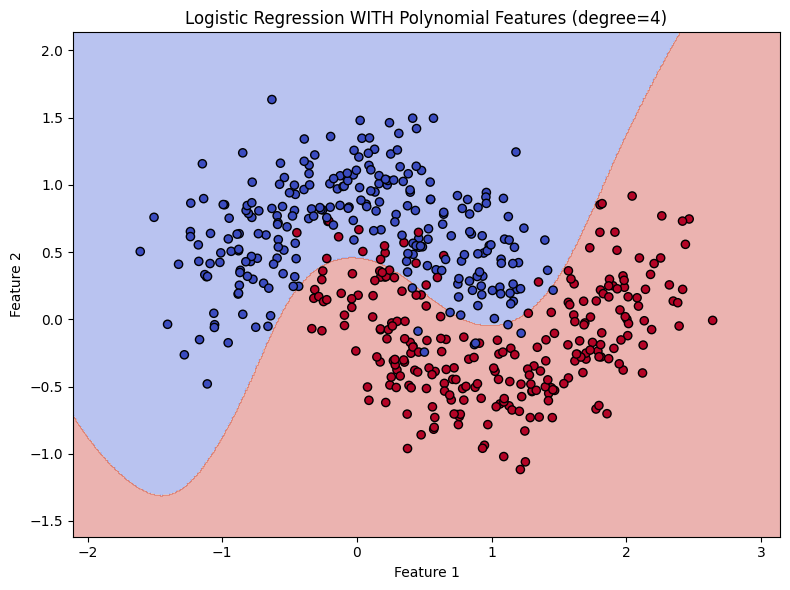

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Non-Linear Dataset
# -----------------------------
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Pipeline: PolynomialFeatures -> LogisticRegression
# -----------------------------
plrc = Pipeline([
    ("polynomial", PolynomialFeatures(degree=4)),  # By default degree = 2
    ("lrc", LogisticRegression(max_iter=5000))
])

# Fit and evaluate
plrc.fit(X_train, y_train)
y_pred = plrc.predict(X_test)

score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy: ", score)
print("Confusion Matrix:\n", cm)

# -----------------------------
# Decision boundary plotting
# -----------------------------
def model_plot(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # classifier can be a Pipeline; it will transform then predict
    Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, cmap='coolwarm', edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# Plot the pipeline's decision boundary over the original data
model_plot(plrc, X, y, "Logistic Regression WITH Polynomial Features (degree=4)")


## **<font color="blue">Degree 5 </font>**

Accuracy:  0.95
Confusion Matrix:
 [[43  0]
 [ 5 52]]


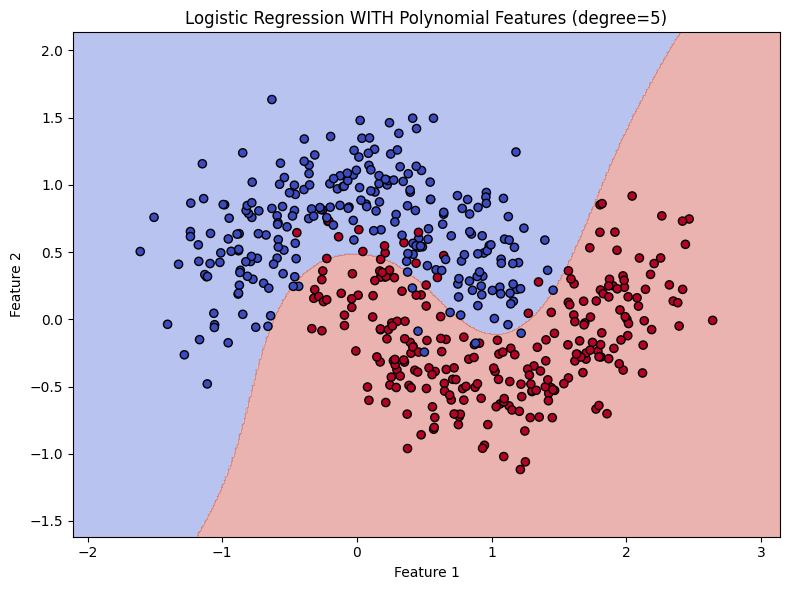

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Non-Linear Dataset
# -----------------------------
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Pipeline: PolynomialFeatures -> LogisticRegression
# -----------------------------
plrc = Pipeline([
    ("polynomial", PolynomialFeatures(degree=5)),  # By default degree = 2
    ("lrc", LogisticRegression(max_iter=5000))
])

# Fit and evaluate
plrc.fit(X_train, y_train)
y_pred = plrc.predict(X_test)

score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy: ", score)
print("Confusion Matrix:\n", cm)

# -----------------------------
# Decision boundary plotting
# -----------------------------
def model_plot(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # classifier can be a Pipeline; it will transform then predict
    Z = clf.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, cmap='coolwarm', edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

# Plot the pipeline's decision boundary over the original data
model_plot(plrc, X, y, "Logistic Regression WITH Polynomial Features (degree=5)")
